### Integrantes: Santiago Parada - Francisco Castro - Natalia Rodriguez - David Cifuentes

# 00 — Preparación de datos 
**Proyecto Retador - Patrones Invisibles: Información, Incertidumbre y Movilidad Urbana**
ML No Supervisado · Universidad de La Sabana · 2026-II

Este notebook produce una sola muestra y una sola zonificación que usan los cuatro roles. Así los números de entropía (Rol 1), clustering (Rol 2) y mezclas gaussianas (Rol 3) se calculan sobre exactamente los mismos viajes y las mismas zonas, y el Rol 4 puede integrarlos sin contradicciones.

**Dataset:** NYC Taxi Trip Duration - https://www.kaggle.com/c/nyc-taxi-trip-duration/data
Se usa únicamente `train.csv`. `test.csv` no contiene `trip_duration` ni `dropoff_datetime` (era el conjunto de predicción de la competencia) y `sample_submission.csv` es solo el formato de envío a Kaggle.

**Flujo:**
1. Carga y diagnóstico del archivo completo
2. Variables derivadas (distancia Haversine, velocidad, variables temporales)
3. Limpieza con reglas explícitas y conteo de lo que elimina cada una
4. Muestreo aleatorio de 50 000 viajes y verificación de representatividad
5. Zonificación geográfica común (K-means sobre coordenadas proyectadas a km)
6. Exportación de archivos para los demás notebooks

## 0. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans

SEMILLA = 42          # fija todos los procesos aleatorios -> resultados reproducibles
N_MUESTRA = 50_000    # tamaño de la muestra de trabajo
K_ZONAS = 20          # número de zonas operativas

# Rutas relativas a la carpeta notebooks/ del repositorio.
# En Google Colab: subir train.csv y cambiar RUTA_DATOS a Path('/content').
RUTA_DATOS = Path('../data')
RUTA_DATOS.mkdir(exist_ok=True)

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 110

## 1. Carga y diagnóstico del archivo completo

In [2]:
df = pd.read_csv(RUTA_DATOS / 'train.csv', parse_dates=['pickup_datetime', 'dropoff_datetime'])
print(f'Registros: {len(df):,}  |  Columnas: {df.shape[1]}')
print(f'Periodo: {df.pickup_datetime.min()}  ->  {df.pickup_datetime.max()}')
print(f'Valores nulos en todo el archivo: {df.isna().sum().sum()}')
df.head()

Registros: 1,458,644  |  Columnas: 11
Periodo: 2016-01-01 00:00:17  ->  2016-06-30 23:59:39
Valores nulos en todo el archivo: 0


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.9822,40.7679,-73.9646,40.7656,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.9804,40.7386,-73.9995,40.7312,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.9790,40.7639,-74.0053,40.7101,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.0100,40.7200,-74.0123,40.7067,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.9731,40.7932,-73.9729,40.7825,N,435


In [3]:
# Diagnóstico de valores extremos: justifica las reglas de limpieza de la sección 3
df[['trip_duration', 'passenger_count',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude']].describe().T

,count,mean,std,min,25%,50%,75%,max
trip_duration,"1,458,644.0000",959.4923,"5,237.4317",1.0000,397.0000,662.0000,"1,075.0000","3,526,282.0000"
passenger_count,"1,458,644.0000",1.6645,1.3142,0.0000,1.0000,1.0000,2.0000,9.0000
pickup_longitude,"1,458,644.0000",-73.9735,0.0709,-121.9333,-73.9919,-73.9817,-73.9673,-61.3355
pickup_latitude,"1,458,644.0000",40.7509,0.0329,34.3597,40.7373,40.7541,40.7684,51.8811
dropoff_longitude,"1,458,644.0000",-73.9734,0.0706,-121.9333,-73.9913,-73.9798,-73.9630,-61.3355
dropoff_latitude,"1,458,644.0000",40.7518,0.0359,32.1811,40.7359,40.7545,40.7698,43.9210


**Lectura del diagnóstico:** Hay coordenadas que caen muy lejos de Nueva York (longitudes cercanas a −122, que corresponden a California), viajes de 1 segundo y viajes de más de un mes, y registros con 0 pasajeros. Ninguno de estos casos representa un viaje real de taxi urbano, así que se filtran con reglas explícitas antes de muestrear.

## 2. Variables derivadas

**Distancia Haversine:** Las coordenadas son ángulos sobre una esfera, no puntos en un plano. Calcular la distancia euclidiana sobre lat/lon mezclaría grados de latitud y de longitud, que no miden lo mismo: en Nueva York, un grado de longitud equivale a unos 84 km y uno de latitud a unos 111 km. La fórmula de Haversine calcula la distancia sobre la superficie de la Tierra:

$$d = 2R \arcsin\sqrt{\sin^2\!\left(\tfrac{\Delta\varphi}{2}\right) + \cos\varphi_1 \cos\varphi_2 \sin^2\!\left(\tfrac{\Delta\lambda}{2}\right)}, \qquad R = 6371 \text{ km}$$

donde $\varphi$ es la latitud y $\lambda$ la longitud, ambas en radianes.

In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia sobre la superficie terrestre (km). Acepta arreglos de numpy."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Verificación con un caso conocido: Times Square -> aeropuerto JFK (~21.7 km en línea recta)
print(f"Times Square -> JFK: {haversine_km(40.7580, -73.9855, 40.6413, -73.7781):.2f} km")

Times Square -> JFK: 21.77 km


In [5]:
df['distancia_km'] = haversine_km(df.pickup_latitude, df.pickup_longitude,
                                  df.dropoff_latitude, df.dropoff_longitude)
df['duracion_min'] = df.trip_duration / 60
df['velocidad_kmh'] = df.distancia_km / (df.trip_duration / 3600)

# Variables temporales
df['hora'] = df.pickup_datetime.dt.hour
df['dia_semana'] = df.pickup_datetime.dt.dayofweek          # 0 = lunes ... 6 = domingo
df['fin_de_semana'] = (df.dia_semana >= 5).astype(int)
df['mes'] = df.pickup_datetime.dt.month

# Franjas operativas del día
def franja(h):
    if h <= 5:   return 'madrugada'   # 00-05
    if h <= 9:   return 'pico_am'     # 06-09
    if h <= 15:  return 'valle'       # 10-15
    if h <= 19:  return 'pico_pm'     # 16-19
    return 'noche'                    # 20-23

ORDEN_FRANJAS = ['madrugada', 'pico_am', 'valle', 'pico_pm', 'noche']
df['franja'] = pd.Categorical(df.hora.map(franja), categories=ORDEN_FRANJAS, ordered=True)

df[['distancia_km', 'duracion_min', 'velocidad_kmh', 'hora', 'dia_semana', 'franja']].head()

,distancia_km,duracion_min,velocidad_kmh,hora,dia_semana,franja
0,1.4985,7.5833,11.8564,17,0,pico_pm
1,1.8055,11.0500,9.8037,0,6,madrugada
2,6.3851,35.4000,10.8222,11,1,valle
3,1.4855,7.1500,12.4657,19,2,pico_pm
4,1.1886,7.2500,9.8366,13,5,valle


## 3. Limpieza con reglas explícitas

Las reglas se aplican en orden y se registra cuántos viajes elimina cada una. Cada regla tiene una justificación física u operativa:

| Regla | Justificación |
|---|---|
| Origen y destino dentro de la caja geográfica de NYC | Excluye errores de GPS (puntos en otros estados o en el océano) |
| Duración entre 1 minuto y 3 horas | Menos de 1 min suele ser un viaje cancelado; más de 3 h, un taxímetro que no se apagó |
| Entre 1 y 6 pasajeros | 0 pasajeros no es un viaje; más de 6 excede la capacidad de un taxi amarillo |
| Distancia de al menos 100 m | Distancia casi nula = origen y destino iguales (error de registro o viaje circular no analizable) |
| Velocidad promedio máxima de 100 km/h | Velocidades mayores son físicamente imposibles en tráfico urbano |

In [6]:
# Caja geográfica que cubre los cinco boroughs y los aeropuertos JFK, LaGuardia y Newark
LON_MIN, LON_MAX = -74.30, -73.70
LAT_MIN, LAT_MAX = 40.50, 40.95

def dentro_nyc(lat, lon):
    return lat.between(LAT_MIN, LAT_MAX) & lon.between(LON_MIN, LON_MAX)

reglas = [
    ('Coordenadas dentro de NYC',  lambda d: dentro_nyc(d.pickup_latitude, d.pickup_longitude)
                                            & dentro_nyc(d.dropoff_latitude, d.dropoff_longitude)),
    ('Duración entre 60 s y 3 h',  lambda d: d.trip_duration.between(60, 3 * 3600)),
    ('Pasajeros entre 1 y 6',      lambda d: d.passenger_count.between(1, 6)),
    ('Distancia >= 0.1 km',        lambda d: d.distancia_km >= 0.1),
    ('Velocidad <= 100 km/h',      lambda d: d.velocidad_kmh <= 100),
]

registro = []
limpio = df.copy()
for nombre, condicion in reglas:
    antes = len(limpio)
    limpio = limpio[condicion(limpio)]
    registro.append({'regla': nombre, 'eliminados': antes - len(limpio), 'restantes': len(limpio)})

registro = pd.DataFrame(registro)
registro['% eliminado del total'] = 100 * registro.eliminados / len(df)
display(registro)
print(f'Retenido: {len(limpio):,} de {len(df):,} viajes ({100 * len(limpio) / len(df):.2f} %)')

,regla,eliminados,restantes,% eliminado del total
0,Coordenadas dentro de NYC,1100,1457544,0.0754
1,Duración entre 60 s y 3 h,10549,1446995,0.7232
2,Pasajeros entre 1 y 6,19,1446976,0.0013
3,Distancia >= 0.1 km,7439,1439537,0.5100
4,Velocidad <= 100 km/h,33,1439504,0.0023


Retenido: 1,439,504 de 1,458,644 viajes (98.69 %)


## 4. Muestreo

**Estrategia:** muestra aleatoria simple de 50 000 viajes sobre el conjunto ya limpio, con semilla fija.

**Por qué 50 000:** Con 20 zonas × 24 horas hay 480 celdas en la tabla de contingencia que usa el Rol 1. Con 50 000 viajes hay en promedio unos 100 viajes por celda, suficiente para estimar probabilidades con estabilidad. A la vez, el tamaño permite correr K-means, DBSCAN y EM en segundos, algo imposible de iterar con 1.4 millones de registros (DBSCAN escala mal con n).

**Por qué aleatoria simple y no un filtro por mes o borough:** El objetivo de UrbanMove es comparar zonas, horas y tipos de día. Filtrar un borough o un mes eliminaría justamente esa variación. El muestreo aleatorio conserva las proporciones naturales de cada hora, día y zona; eso se verifica abajo.

In [7]:
muestra = limpio.sample(n=N_MUESTRA, random_state=SEMILLA).reset_index(drop=True)
print(f'Muestra: {len(muestra):,} viajes  ({100 * N_MUESTRA / len(limpio):.2f} % del conjunto limpio)')

Muestra: 50,000 viajes  (3.47 % del conjunto limpio)


**Verificación de representatividad:** Se compara la distribución de la hora del día, el día de la semana y el mes en la muestra contra el conjunto limpio completo. La métrica es la **divergencia KL** en bits, $D_{KL}(P_{\text{muestra}} \| P_{\text{completo}}) = \sum_x P_{\text{muestra}}(x) \log_2 \frac{P_{\text{muestra}}(x)}{P_{\text{completo}}(x)}$: vale 0 si las distribuciones son idénticas. Se reporta en milibits (milésimas de bit): valores cercanos a 0 indican que la muestra reproduce la población.

In [8]:
def kl_bits(p, q):
    """Divergencia KL en bits entre dos distribuciones sobre las mismas categorías."""
    p, q = np.asarray(p, float), np.asarray(q, float)
    m = p > 0
    return np.sum(p[m] * np.log2(p[m] / q[m]))

filas = []
for var in ['hora', 'dia_semana', 'mes', 'fin_de_semana']:
    p = muestra[var].value_counts(normalize=True).sort_index()
    q = limpio[var].value_counts(normalize=True).sort_index()
    filas.append({'variable': var,
                  'KL muestra||completo (milibits)': 1000 * kl_bits(p, q.loc[p.index]),
                  'máx. diferencia de proporción (p.p.)': 100 * (p - q.loc[p.index]).abs().max()})
pd.DataFrame(filas)

,variable,KL muestra||completo (milibits),máx. diferencia de proporción (p.p.)
0,hora,0.3222,0.1605
1,dia_semana,0.0211,0.1454
2,mes,0.0410,0.1743
3,fin_de_semana,0.0024,0.0819


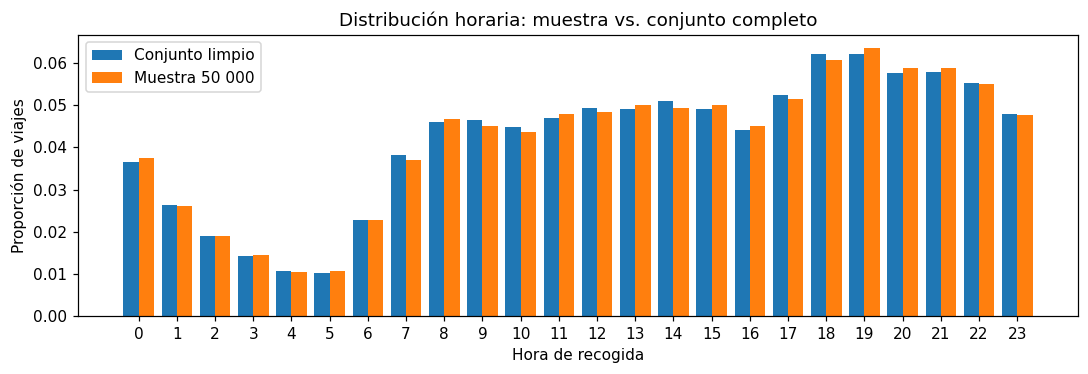

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.5))
w = 0.4
horas = np.arange(24)
ax.bar(horas - w/2, limpio.hora.value_counts(normalize=True).sort_index(), w, label='Conjunto limpio')
ax.bar(horas + w/2, muestra.hora.value_counts(normalize=True).sort_index(), w, label='Muestra 50 000')
ax.set(xlabel='Hora de recogida', ylabel='Proporción de viajes', xticks=horas,
       title='Distribución horaria: muestra vs. conjunto completo')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Zonificación geográfica común

Para medir entropía por zona (Rol 1) y comparar perfiles por zona (Roles 2, 3 y 4) todos necesitan **las mismas zonas discretas**. Se construyen con K-means sobre los puntos de recogida.

**Por qué proyectar a kilómetros antes de K-means:** K-means usa distancia euclidiana. Sobre lat/lon crudos, 0.01° de longitud (≈0.84 km) pesaría lo mismo que 0.01° de latitud (≈1.11 km), así que los clusters saldrían deformados. Se aplica una proyección local equirectangular:

$$x = (\lambda - \lambda_0)\cdot 111.32 \cos\varphi_0, \qquad y = (\varphi - \varphi_0)\cdot 110.57$$

Dentro de un área del tamaño de NYC, la distancia euclidiana sobre $(x, y)$ en km aproxima la distancia Haversine con error menor al 1 %. Se verifica abajo.

**Por qué K = 20:** Es una decisión operativa: 20 zonas es una granularidad que un despachador puede gestionar (cada zona agrupa unos 2 500 viajes de la muestra) y deja celdas pobladas en la tabla zona × hora. Esta zonificación es un insumo común, no el análisis de clustering del Rol 2, que selecciona K formalmente con codo y silueta. La entropía máxima posible con 20 zonas es $\log_2 20 = 4.32$ bits.

In [10]:
LAT0 = limpio.pickup_latitude.mean()
LON0 = limpio.pickup_longitude.mean()

def proyectar_km(lat, lon):
    """Proyección local equirectangular: lat/lon (grados) -> x, y (km) centrados en NYC."""
    x = (lon - LON0) * 111.32 * np.cos(np.radians(LAT0))
    y = (lat - LAT0) * 110.57
    return np.column_stack([x, y])

XY_origen = proyectar_km(muestra.pickup_latitude, muestra.pickup_longitude)
XY_destino = proyectar_km(muestra.dropoff_latitude, muestra.dropoff_longitude)

# Verificación: distancia euclidiana proyectada vs. Haversine
d_proy = np.linalg.norm(XY_destino - XY_origen, axis=1)
error_rel = np.abs(d_proy - muestra.distancia_km) / muestra.distancia_km
print(f'Error relativo de la proyección frente a Haversine: mediana {100*error_rel.median():.3f} %, '
      f'percentil 99 {100*error_rel.quantile(0.99):.3f} %')

Error relativo de la proyección frente a Haversine: mediana 0.360 %, percentil 99 0.562 %


In [11]:
kmeans_zonas = KMeans(n_clusters=K_ZONAS, init='k-means++', n_init=10, random_state=SEMILLA)
kmeans_zonas.fit(XY_origen)

# Las zonas se entrenan con las recogidas y se aplican igual a los destinos,
# para que origen y destino compartan exactamente el mismo mapa.
# Se ordenan de mayor a menor volumen de recogidas: la zona 0 es la de más demanda.
etiquetas_orig = kmeans_zonas.predict(XY_origen)
orden = pd.Series(etiquetas_orig).value_counts().index
renombre = {vieja: nueva for nueva, vieja in enumerate(orden)}

muestra['zona_origen'] = pd.Series(etiquetas_orig).map(renombre).values
muestra['zona_destino'] = pd.Series(kmeans_zonas.predict(XY_destino)).map(renombre).values

In [12]:
# Centroides en lat/lon (inverso de la proyección) y volumen por zona
cent_xy = kmeans_zonas.cluster_centers_[orden]
centroides = pd.DataFrame({
    'zona': range(K_ZONAS),
    'lat': LAT0 + cent_xy[:, 1] / 110.57,
    'lon': LON0 + cent_xy[:, 0] / (111.32 * np.cos(np.radians(LAT0))),
    'recogidas': muestra.zona_origen.value_counts().sort_index().values,
    'destinos': muestra.zona_destino.value_counts().reindex(range(K_ZONAS), fill_value=0).values,
})
centroides['% recogidas'] = 100 * centroides.recogidas / N_MUESTRA
centroides

,zona,lat,lon,recogidas,destinos,% recogidas
0,0,40.7604,-73.9697,4860,4333,9.7200
1,1,40.7525,-73.9919,4794,4319,9.5880
2,2,40.7634,-73.9845,4642,4070,9.2840
3,3,40.7502,-73.9773,4195,4147,8.3900
4,4,40.7383,-73.9860,4105,3780,8.2100
5,5,40.7703,-73.9588,3583,3461,7.1660
6,6,40.7242,-73.9896,3437,3011,6.8740
7,7,40.7421,-74.0010,3331,2749,6.6620
8,8,40.7808,-73.9530,3008,3414,6.0160
9,9,40.7292,-74.0025,2655,2348,5.3100


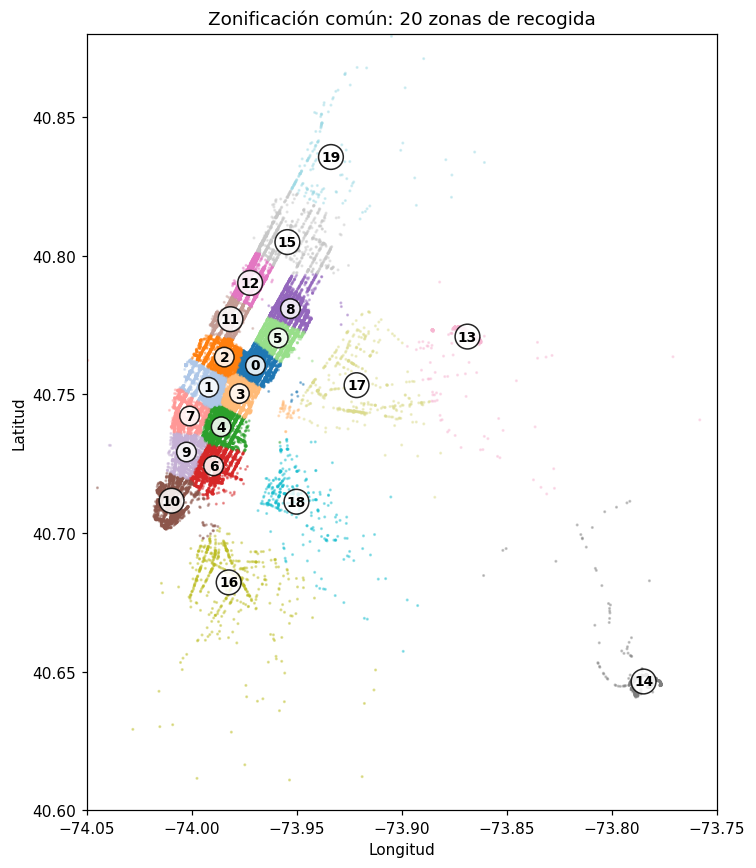

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(muestra.pickup_longitude, muestra.pickup_latitude,
           c=muestra.zona_origen, cmap='tab20', s=1, alpha=0.4)
for _, z in centroides.iterrows():
    ax.annotate(int(z.zona), (z.lon, z.lat), ha='center', va='center', fontsize=9, weight='bold',
                bbox=dict(boxstyle='circle,pad=0.2', fc='white', alpha=0.85))
ax.set(xlabel='Longitud', ylabel='Latitud', title=f'Zonificación común: {K_ZONAS} zonas de recogida',
       xlim=(-74.05, -73.75), ylim=(40.60, 40.88))
ax.set_aspect(1 / np.cos(np.radians(LAT0)))   # aspecto correcto del mapa
plt.tight_layout(); plt.show()

## 6. Resumen de la muestra final

In [14]:
cols_resumen = ['distancia_km', 'duracion_min', 'velocidad_kmh', 'passenger_count']
display(muestra[cols_resumen].describe().T)
print('Viajes por franja:')
display(muestra.franja.value_counts().sort_index().to_frame('viajes')
        .assign(pct=lambda t: 100 * t.viajes / N_MUESTRA))
print(f'Fin de semana: {100 * muestra.fin_de_semana.mean():.1f} % de los viajes')

,count,mean,std,min,25%,50%,75%,max
distancia_km,"50,000.0000",3.4781,3.8994,0.1002,1.2650,2.1330,3.9320,40.8542
duracion_min,"50,000.0000",14.1159,11.0457,1.0000,6.7333,11.1167,17.9833,134.9500
velocidad_kmh,"50,000.0000",14.4854,7.5649,0.1074,9.2408,12.9109,17.9936,68.7085
passenger_count,"50,000.0000",1.6574,1.3093,1.0000,1.0000,1.0000,2.0000,6.0000


Viajes por franja:


,viajes,pct
franja,,
madrugada,5916,11.8320
pico_am,7567,15.1340
valle,14465,28.9300
pico_pm,11029,22.0580
noche,11023,22.0460


Fin de semana: 28.6 % de los viajes


## 7. Exportación

In [15]:
columnas = ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count',
            'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
            'store_and_fwd_flag', 'trip_duration',
            'distancia_km', 'duracion_min', 'velocidad_kmh',
            'hora', 'dia_semana', 'fin_de_semana', 'mes', 'franja',
            'zona_origen', 'zona_destino']

muestra[columnas].to_csv(RUTA_DATOS / 'muestra_50k.csv', index=False)
centroides.to_csv(RUTA_DATOS / 'centroides_zonas.csv', index=False)
registro.to_csv(RUTA_DATOS / 'registro_limpieza.csv', index=False)

print('Archivos generados en', RUTA_DATOS.resolve())
for f in ['muestra_50k.csv', 'centroides_zonas.csv', 'registro_limpieza.csv']:
    print(f'  {f:25s} {(RUTA_DATOS / f).stat().st_size / 1e6:6.2f} MB')

Archivos generados en C:\Users\santi\OneDrive\Desktop\QUINTO SEMESTRE\NO SUPERVISADO\PROYECTO_2\data
  muestra_50k.csv            10.33 MB
  centroides_zonas.csv        0.00 MB
  registro_limpieza.csv       0.00 MB
